## <space><space> GridMind : AI<br>~ Unmask The Invisible !

In [48]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
import warnings
warnings.filterwarnings("ignore")


- To make our AI predict the state when our grid will fail, we are making a situation where the simulink grid is crashed and then we transfer this data here so that our model can learn what is the condition when the grid actually fails in real time.

In [49]:
# Loading the Crash data

data = loadmat("simulation_data_crash.mat")
t = data["t"].squeeze()
df = data["df"].squeeze()
data_frame = pd.DataFrame({"Time":t,
                           "Frequency_Change" : df})
data_frame.head()

,Time,Frequency_Change
0,0.0,0.0
1,0.4,0.0
2,0.8,0.0
3,1.2,0.0
4,1.6,0.0


Feature Engineering :
- Currently our model has only one feature of frequency change which is not enough to establish a strong relationship to predict if the grid is going to crash or not, so we are going to add another feature.

- The next feature we are going to add is the rate of change of frequency, this tells us how fast the frequency drop is going relative to the nominal time scale of the simultion.

- For simplicity, symbol used in Rate of Change of Frequency = RoCof, lets add this then

In [50]:
dt = data_frame["Time"].diff().mean()

- Since our simulation time and reading time is highly correleated, the denominator for the rate of change, dt i.e. time difference between the noting of each reading is constant and is equal throughout the reading itself, so we are just finding out dt and then now finding the Rate of Change of Frequency.

In [51]:
data_frame["RoCoF"] = data_frame["Frequency_Change"].diff()/dt
data_frame.head()

,Time,Frequency_Change,RoCoF
0,0.0,0.0,NaN
1,0.4,0.0,0.0
2,0.8,0.0,0.0
3,1.2,0.0,0.0
4,1.6,0.0,0.0


In [52]:
data_frame.isnull().sum()

Time                0
Frequency_Change    0
RoCoF               1
dtype: int64

In [53]:
# Removing the Null value for further data processing

data_frame = data_frame.dropna().reset_index(drop=True)
data_frame.isnull().sum()

Time                0
Frequency_Change    0
RoCoF               0
dtype: int64

- Now we are going to set a certain threshold of change in frequency, after this threshold is crossed then we will say that there is high probablity of collaspe risk, so adding the columns in dataframe as per this concept.

In [54]:
critical_threshold = -5.0 # Max frequency change allowed, else grid gone.
data_frame["Collaspe_Risk"] = (data_frame["Frequency_Change"] < critical_threshold).astype(int)

In [55]:
data_frame.head() # Showing no Grid Collaspe

,Time,Frequency_Change,RoCoF,Collaspe_Risk
0,0.4,0.0,0.0,0
1,0.8,0.0,0.0,0
2,1.2,0.0,0.0,0
3,1.6,0.0,0.0,0
4,2.0,0.0,0.0,0


In [56]:
data_frame.tail() # Showing Grid Collaspe

,Time,Frequency_Change,RoCoF,Collaspe_Risk
185,19.608149,-0.003973,-0.000060,0
186,19.696774,-0.003980,-0.000070,0
187,19.800717,-0.003988,-0.000074,0
188,19.922574,-0.003997,-0.000091,0
189,20.000000,-0.004003,-0.000054,0


In [57]:
print(data_frame["Collaspe_Risk"].value_counts())

Collaspe_Risk
0    190
Name: count, dtype: int64


Why count of Collaspe Risk is only 0s ?
- An important insight is learnt here, in simulink scope at the top left corner of the scope, if we see it clearly then we can observe that it has the scale of 10e-4, so all our frequency change data is scaled in this format.

But in dataframe to get actual values, we must multiply with 10e-4 to match the scale, but this is not done because even in this scale the numbers are very small and if we multiply it with the scaling factor then the numbers will further become more smaller, so lets just keep the scaled data.

To compensate this problem, we will set our threshold value as per the scaled data we have got from the simulink.

Quick Recap on the syntax : 5 x 10^(-4) = 5e-4

In [58]:
critical_threshold = -5e-4 # Max frequency change allowed, else grid gone.
data_frame["Collaspe_Risk"] = (data_frame["Frequency_Change"] < critical_threshold).astype(int)
print(data_frame["Collaspe_Risk"].value_counts()) # NICE !

Collaspe_Risk
1    166
0     24
Name: count, dtype: int64


- If we use only the present frequency and say its a grid crash or not, our model is just using the threshold value of frequency we have provided.

- To make our model " predict " the grid collaspe, we are going to shift the readings three steps ahead of time for the training.

- This meaning that each reading is taken at around 0.4 sec of time interval so our model will predict the grid collaspe three step time ahead which means, grid collaspe will be predicted 1.2 sec before it actually happens.

In [59]:
Forecast_steps = 3
data_frame["Future_Collaspe_Risk"] = data_frame["Collaspe_Risk"].shift(-Forecast_steps)
data_frame.tail()

,Time,Frequency_Change,RoCoF,Collaspe_Risk,Future_Collaspe_Risk
185,19.608149,-0.003973,-0.000060,1,1.0
186,19.696774,-0.003980,-0.000070,1,1.0
187,19.800717,-0.003988,-0.000074,1,NaN
188,19.922574,-0.003997,-0.000091,1,NaN
189,20.000000,-0.004003,-0.000054,1,NaN


In [60]:
# Removing the NaN values :

data_frame = data_frame.dropna().reset_index(drop=True)
data_frame.isnull().sum()

Time                    0
Frequency_Change        0
RoCoF                   0
Collaspe_Risk           0
Future_Collaspe_Risk    0
dtype: int64

---
MODEL TRAINING PHASE :

In [61]:
# Data Splitting :

features = ["Frequency_Change","RoCoF"]
x = data_frame[features]
y = data_frame["Future_Collaspe_Risk"]

MODEL SELECTION : RandomForest

- For this project I have selected Random Forest as my model because, up till this point my data is very non uniform and non linear ( Frequency cahnge hopes highs and lows ) and also have very few rows of data ( Like around 200 rows, so deep neural networks is out of the equation ).

- Boosting isnt used as XGBoost algorithms requires very fine tuning or else it is very prone to be overfit, so for now lets just stick to the Random Forest.

In [62]:
# Training Function :

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report
from sklearn.model_selection import train_test_split,cross_val_score

def training_function(model,x,y):
    x_train,x_test,y_train,y_test = train_test_split(x,y,shuffle=False)
    model_name = model.fit(x_train,y_train)
    probablities = model.predict_proba(x_test)
    model_prediction_value = model.predict(x_test)

    cv_score = cross_val_score(model,x_train,y_train,
                scoring = "accuracy",cv = 5)
    cv_score = np.abs(np.mean(cv_score))

    print("--- MODEL REPORT ----")
    print("MODEL TYPE :",model)
    print("CV SCORE :",cv_score)
    
    print("\n--- CLASSIFICATION REPORT ---")

    unique_classes_in_test = sorted(y_test.unique())
    all_labels = {0: "Safe Grid (0)", 1: "Collapse Risk (1)"}
    dynamic_labels = [all_labels[c] for c in unique_classes_in_test]
    
    report = classification_report(y_test, model_prediction_value, 
                                   target_names=dynamic_labels)
    print(report)

    fig,(axs1,axs2) = plt.subplots(1,2,figsize  = (10,5))
    cm = confusion_matrix(y_test,model_prediction_value)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                        display_labels=dynamic_labels)
    disp.plot(cmap = "Blues",ax = axs1,colorbar = False)
    axs1.set_title("CONFUSION MATRIX : REALITY VS PREDICTION ")
    axs1.tick_params(axis='y', rotation=90)


    importances = pd.Series(model.feature_importances_, 
                    index=x.columns).sort_values(ascending=False)
    importances.plot(kind='bar', ax=axs2, color='teal')
    axs2.set_title("Feature Importance ")
    axs2.grid(axis='y', linestyle='--', alpha=0.7)
    axs2.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
    
    return model_name
    

IMPORTANT POINTS TO BE NOTED :

- Since we are going to "predict" the condition of the grid about 1.2 seconds prior to when it actually happens, we must keep the "shuffling mode" false, this is because each data prior to one another is highly related to determine the future collaspe as our project is "TimeSeries prediction".

- Here, our confusion matrix is just 1 x 1 matrix instead of showing two states of healthy and collaspe risk i.e. 2 x 2 grid matrix because, we have turned off the shuffle so that our model learns through periodic change in frequency and predicts the trend. So during the train test split, around 80% of data is used by model to train and rest 20% is used for testing, confusion matrix is shown for the testing set of data, and since shuffling is off, at the end of the simulation only collaspe case is present, thus it shows only collaspe risk phase.

- For Regression tasks, we use mean square error but since our model is predicitng for a classification problem, in cv scoring we are using "accuracy" which is simply the ratio of total correct predicitons to total samples.




--- MODEL REPORT ----
MODEL TYPE : RandomForestClassifier(random_state=42)
CV SCORE : 0.9142857142857143

--- CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

Collapse Risk (1)       1.00      1.00      1.00        47

         accuracy                           1.00        47
        macro avg       1.00      1.00      1.00        47
     weighted avg       1.00      1.00      1.00        47



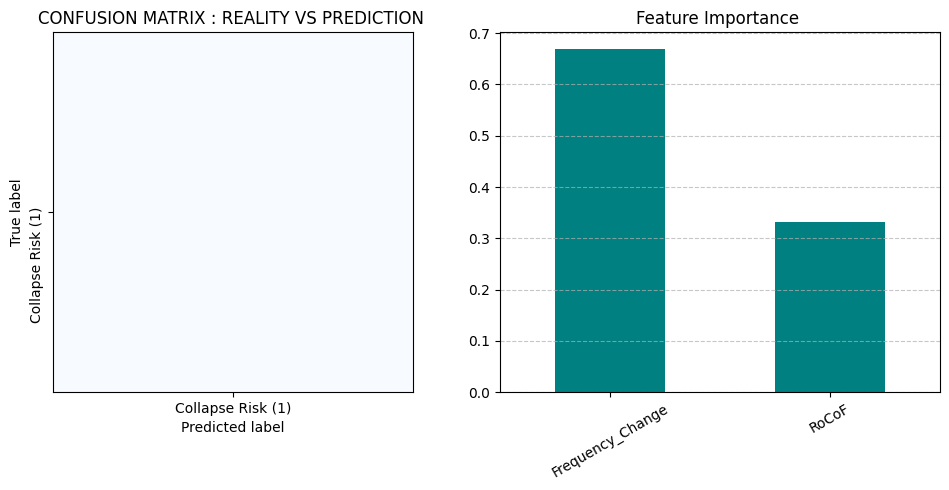

In [63]:
random_forest_model = training_function(RandomForestClassifier(n_estimators=100,random_state=42),x,y)

---
TESTING THE MODEL UP TILL THIS POINT :

- As we have discussed that our confusion matrix just shows the 1 x 1 matrix due to the nature of train test splitting, we are exporting new test sample data from the simulink.

- The test data has slightly different parameters and loading so that we can actually see if our model is performing good or just memorizing the facts and figures.

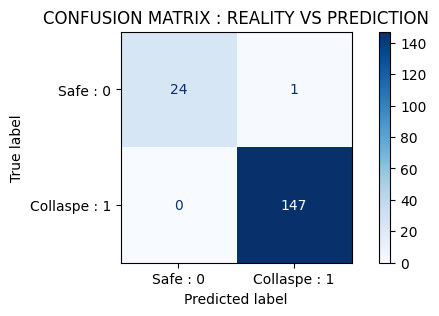

<Figure size 640x480 with 0 Axes>

In [64]:
# TESTING OF THE MODEL ACCURACY :

raw_test_data = loadmat("simulation_data_crash_test.mat")
t_test = raw_test_data["t"].squeeze()
df_test = raw_test_data["df"].squeeze()

test_df = pd.DataFrame({
                            "Time": t_test,
                            "Frequency_Change": df_test
                        })

dt_test = test_df["Time"].diff().mean()
test_df["RoCoF"] = test_df["Frequency_Change"].diff() / dt_test
test_df["Collaspe_Risk"] = (test_df["Frequency_Change"] < -5e-4).astype(int)
FORECAST_STEPS = 3
test_df["Future_Collaspe_Risk"] = test_df["Collaspe_Risk"].shift(-FORECAST_STEPS)
test_df = test_df.dropna().reset_index(drop=True)

x_test = test_df[["Frequency_Change","RoCoF"]]
y_test = test_df["Future_Collaspe_Risk"]

model_prediction = random_forest_model.predict(x_test)

fig,axs = plt.subplots(figsize = [7,3])
cm_test = confusion_matrix(y_test, model_prediction)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                display_labels=["Safe : 0", "Collaspe : 1"])
disp_test.plot(cmap="Blues",ax = axs)
plt.title("CONFUSION MATRIX : REALITY VS PREDICTION")
plt.show()
plt.tight_layout()


Testing Reasult Conclusions :

- The test reasult obtained in our system is very well done. This signifies that our model is not prone towards the problem of memorizing the data that I was abit concerned about as we had used Random Forest model.

- This test reasult doesnt have any False Negative error meaning that our system up till this date is very reliable and concrete in nature. 

- We can observe that there is 1 False Negative error given by our model, which is completly practical and is well acceptable, as it doesnt compromise on system's reliablity in any means.

---
Advanced Feature Engineering :

- Currently we have added RoCoF as our additional feature, which makes our model good, but for making our model industrial level and with greater accuracy we are adding for features.

Frequency Accleration :

- Firstly we are adding accleartion of frequency which allows our model to predict the grid collaspe much more efficiently as we can dive deep into the motion taken by our frequency vector throughout the time space.

In [65]:
df_advanced = data_frame[["Time","Frequency_Change","RoCoF",
                          "Collaspe_Risk","Future_Collaspe_Risk"]]
df_advanced["Frequency_Accleration"] = df_advanced["RoCoF"].diff() / dt
df_advanced.head()

,Time,Frequency_Change,RoCoF,Collaspe_Risk,Future_Collaspe_Risk,Frequency_Accleration
0,0.4,0.0,0.0,0,0.0,NaN
1,0.8,0.0,0.0,0,0.0,0.0
2,1.2,0.0,0.0,0,0.0,0.0
3,1.6,0.0,0.0,0,0.0,0.0
4,2.0,0.0,0.0,0,0.0,0.0


Rolling Frequency Change :

- Now we are going to add another feature of rolling window for frequency change. Sometimes the frequency for a very small instance might flicker and change due to some other causes like noise or any other things which doesnt necessarily cause the grid collaspe, in order to tackle with this type of situation we are going to add rolling window.

- This allows our model to tenditively see the time duration or interval upto which our frequency change occurs and can distinguish between the noise or rather grid collaspe.

In [66]:
df_advanced["df_RollingMean"] = df_advanced["Frequency_Change"].rolling(window = 3).mean()
df_advanced.head()

,Time,Frequency_Change,RoCoF,Collaspe_Risk,Future_Collaspe_Risk,Frequency_Accleration,df_RollingMean
0,0.4,0.0,0.0,0,0.0,NaN,NaN
1,0.8,0.0,0.0,0,0.0,0.0,NaN
2,1.2,0.0,0.0,0,0.0,0.0,0.0
3,1.6,0.0,0.0,0,0.0,0.0,0.0
4,2.0,0.0,0.0,0,0.0,0.0,0.0


Cumulative Drop :

- Generators of the grid can withstand a deep frequency spike that lasts for just fractions of seconds but cannot withstand a slight drop in frequency lasting for a drastic time as stree on the generator instantly increases.

- This features calculates the area bounded by the frequnecy change curve in the time domain which allows us to visualize the stress tolerance levels of the mechanical equipments in our grid.

In [67]:
df_advanced["Cumulative_Drop"] = df_advanced["Frequency_Change"].cumsum() * dt
df_advanced.head()

,Time,Frequency_Change,RoCoF,Collaspe_Risk,Future_Collaspe_Risk,Frequency_Accleration,df_RollingMean,Cumulative_Drop
0,0.4,0.0,0.0,0,0.0,NaN,NaN,0.0
1,0.8,0.0,0.0,0,0.0,0.0,NaN,0.0
2,1.2,0.0,0.0,0,0.0,0.0,0.0,0.0
3,1.6,0.0,0.0,0,0.0,0.0,0.0,0.0
4,2.0,0.0,0.0,0,0.0,0.0,0.0,0.0


In [68]:
data_frame = df_advanced
data_frame = data_frame.dropna().reset_index(drop=True)
data_frame.isnull().sum()

Time                     0
Frequency_Change         0
RoCoF                    0
Collaspe_Risk            0
Future_Collaspe_Risk     0
Frequency_Accleration    0
df_RollingMean           0
Cumulative_Drop          0
dtype: int64

In [69]:
data_frame.head()

,Time,Frequency_Change,RoCoF,Collaspe_Risk,Future_Collaspe_Risk,Frequency_Accleration,df_RollingMean,Cumulative_Drop
0,1.2,0.000000e+00,0.000000e+00,0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
1,1.6,0.000000e+00,0.000000e+00,0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
2,2.0,0.000000e+00,0.000000e+00,0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
3,2.0,0.000000e+00,0.000000e+00,0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
4,2.0,-2.842171e-16,-2.700062e-15,0,0.0,-2.565059e-14,-9.473903e-17,-2.991759e-17


--- 
TESTING WITH NEW FEATURES :

- Now that we have made added new features to our model, lets test our model and see how it performs on the testing set we had created before hand. 

- Since we are making a seperate testing set sample, we are not going to use the train test split of scikit learn but rather use the full data sample for training operation.

In [70]:
# Data splitting :

features = ["Frequency_Change","RoCoF","Frequency_Accleration",
     "df_RollingMean","Cumulative_Drop"]

x = data_frame[features]
y = data_frame["Future_Collaspe_Risk"]


In [71]:
# Training Function :

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def new_training_function(model,x,y):
    x_train,y_train= x,y
    
    model_name = model.fit(x_train,y_train)

    cv_score = cross_val_score(model,x_train,y_train,
                scoring = "accuracy",cv = 5)
    cv_score = np.abs(np.mean(cv_score))

    print("--- MODEL REPORT ----")
    print("MODEL TYPE :",model)
    print("CV SCORE :",cv_score)
    
    fig,axs = plt.subplots(figsize  = (10,5))

    importances = pd.Series(model.feature_importances_, 
                    index=x.columns).sort_values(ascending=False)
    importances.plot(kind='bar', ax=axs, color='teal')
    axs.set_title("Feature Importance ")
    axs.grid(axis='y', linestyle='--', alpha=0.7)
    axs.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
    
    return model_name
    

--- MODEL REPORT ----
MODEL TYPE : RandomForestClassifier()
CV SCORE : 0.908108108108108


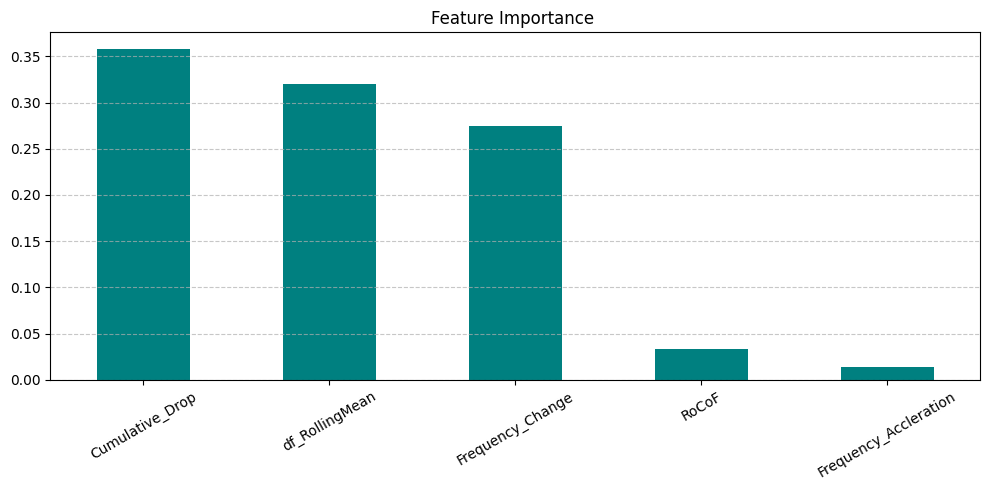

In [72]:
Random_Forest_Model = new_training_function(model = RandomForestClassifier(),
                        x = data_frame[features],y = data_frame["Future_Collaspe_Risk"])

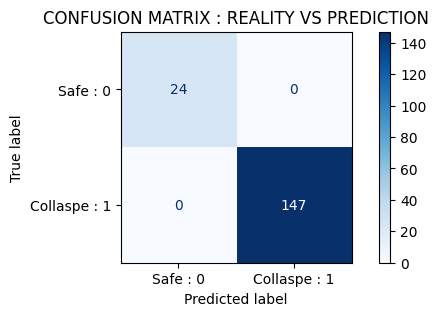

<Figure size 640x480 with 0 Axes>

In [73]:
# TESTING OF THE MODEL ACCURACY :

raw_test_data = loadmat("simulation_data_crash_test.mat")
t_test = raw_test_data["t"].squeeze()
df_test = raw_test_data["df"].squeeze()

test_df = pd.DataFrame({
                            "Time": t_test,
                            "Frequency_Change": df_test
                        })

dt_test = test_df["Time"].diff().mean()
test_df["RoCoF"] = test_df["Frequency_Change"].diff() / dt_test
test_df["Collaspe_Risk"] = (test_df["Frequency_Change"] < -5e-4).astype(int)
FORECAST_STEPS = 3
test_df["Future_Collaspe_Risk"] = test_df["Collaspe_Risk"].shift(-FORECAST_STEPS)
test_df["Frequency_Accleration"] = test_df["RoCoF"].diff() / dt
test_df["df_RollingMean"] = test_df["Frequency_Change"].rolling(window = 3).mean()
test_df["Cumulative_Drop"] = test_df["Frequency_Change"].cumsum() * dt


test_df = test_df.dropna().reset_index(drop=True)

x_test = test_df[features]
y_test = test_df["Future_Collaspe_Risk"]

model_prediction = Random_Forest_Model.predict(x_test)

fig,axs = plt.subplots(figsize = [7,3])
cm_test = confusion_matrix(y_test, model_prediction)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                display_labels=["Safe : 0", "Collaspe : 1"])
disp_test.plot(cmap="Blues",ax = axs)
plt.title("CONFUSION MATRIX : REALITY VS PREDICTION")
plt.show()
plt.tight_layout()


---
SIMULATING REAL WORLD BEHAVIOUR :

- If our model is only trained on ideal data then when it encounters the real world behaviour it can overfit and cannot generalize the behaviour well beacause practically the readings given by the instruments are quiet noisy.

- So, in order to make our model more robust into these kind of situation, we are going to add some noise in our data and make our model less prone to such ideal situation training behaviour.

In [74]:
def add_noise(dataframe,columns_to_noise,noise_level = 0.01): # Industry Standard 1% Noise

    noised_df = dataframe.copy()
    np.random.seed(42) # Setting a constant randomness for proper visualization
    for col in columns_to_noise:
        signal_std = noised_df[col].std() # Standard Deviation Calculation
        noise = np.random.normal(loc = 0.0,
                        scale = signal_std*noise_level,
                        size = len(noised_df))
        noised_df[col] = noised_df[col] + noise

    return noised_df

---
Final Model Training :

- Now that we have made noise addition function, lets train our model on noisy data, we will add noise to our DataFrame such that it can showcase practical behaviour of the grid.

--- MODEL REPORT ----
MODEL TYPE : RandomForestClassifier(random_state=42)
CV SCORE : 0.9027027027027026


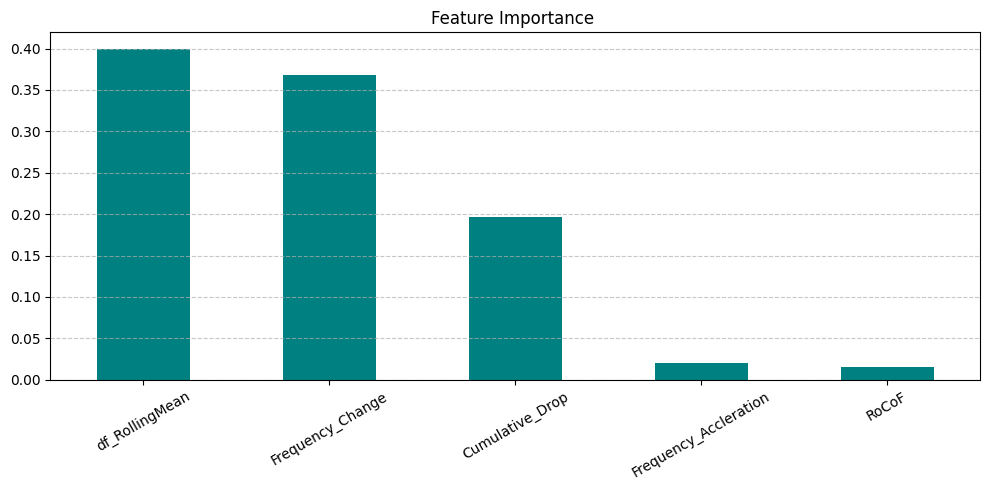

In [75]:
data_frame = add_noise(dataframe=data_frame,columns_to_noise=features,noise_level=0.01)
GridMind_Model = new_training_function(model = RandomForestClassifier(n_estimators=100,
    random_state=42),x = data_frame[features],y = data_frame["Future_Collaspe_Risk"])


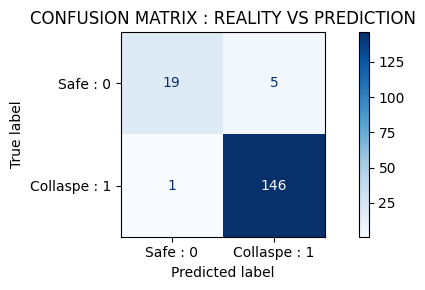

In [76]:
# FINAL TESTING ON VERY NOISY DATA

raw_test_data = loadmat("simulation_data_crash_test.mat")
t_test = raw_test_data["t"].squeeze()
df_test = raw_test_data["df"].squeeze()

test_df = pd.DataFrame({
                            "Time": t_test,
                            "Frequency_Change": df_test
                        })

dt_test = test_df["Time"].diff().mean()
test_df["RoCoF"] = test_df["Frequency_Change"].diff() / dt_test
test_df["Collaspe_Risk"] = (test_df["Frequency_Change"] < -5e-4).astype(int)
FORECAST_STEPS = 3
test_df["Future_Collaspe_Risk"] = test_df["Collaspe_Risk"].shift(-FORECAST_STEPS)
test_df["Frequency_Accleration"] = test_df["RoCoF"].diff() / dt_test
test_df["df_RollingMean"] = test_df["Frequency_Change"].rolling(window = 3).mean()
test_df["Cumulative_Drop"] = test_df["Frequency_Change"].cumsum() * dt_test


test_df = test_df.dropna().reset_index(drop=True)


# ---------- 10% NOISE ADDITION ------------------- #

test_df = add_noise(test_df,features,0.1)

# ------------------------------------------------- #

x_test = test_df[features]
y_test = test_df["Future_Collaspe_Risk"]

model_prediction = GridMind_Model.predict(x_test)

fig,axs = plt.subplots(figsize = [7,3])
cm_test = confusion_matrix(y_test, model_prediction)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                display_labels=["Safe : 0", "Collaspe : 1"])
disp_test.plot(cmap="Blues",ax = axs)
plt.title("CONFUSION MATRIX : REALITY VS PREDICTION")
plt.tight_layout()
plt.show()


In [77]:
def TestingFunction(file_name,threshold_frequency):

    raw_test_data = loadmat(file_name)
    t_test = raw_test_data["t"].squeeze()
    df_test = raw_test_data["df"].squeeze()

    test_df = pd.DataFrame({
                                "Time": t_test,
                                "Frequency_Change": df_test
                            })

    dt_test = test_df["Time"].diff().mean()
    test_df["RoCoF"] = test_df["Frequency_Change"].diff() / dt_test
    test_df["Collaspe_Risk"] = ((test_df["Frequency_Change"] < threshold_frequency)).astype(int)
    FORECAST_STEPS = 3
    test_df["Future_Collaspe_Risk"] = test_df["Collaspe_Risk"].shift(-FORECAST_STEPS)
    test_df["Frequency_Accleration"] = test_df["RoCoF"].diff() / dt_test
    test_df["df_RollingMean"] = test_df["Frequency_Change"].rolling(window = 3).mean()
    test_df["Cumulative_Drop"] = test_df["Frequency_Change"].cumsum() * dt_test


    test_df = test_df.dropna().reset_index(drop=True)

    x_test = test_df[features]
    y_test = test_df["Future_Collaspe_Risk"]

    model_prediction = GridMind_Model.predict(x_test)

    fig,axs = plt.subplots(figsize = [7,3])
    cm_test = confusion_matrix(y_test, model_prediction)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                    display_labels=["Safe : 0", "Collaspe : 1"])
    disp_test.plot(cmap="Blues",ax = axs)
    plt.title("CONFUSION MATRIX : REALITY VS PREDICTION")
    plt.tight_layout()
    plt.show()

    

---
MODEL REFINEMENT :
- Now that our model is trained to predict if the grid collaspes or not, we are going to supply it with simulink data where the grid actually doesnt collaspe but the frequency change falls back up and settles at steady state error

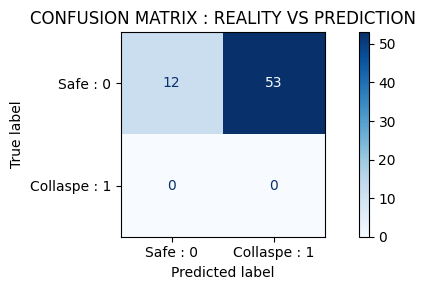

In [78]:
TestingFunction("simulation_data_recovery.mat",-6e-3)

--- 
MODEL TRAINING LIMIT REACHED !
- Here a very important observation has been observed, since our model was trained on conidtion where frequency goes down and it never settles back up, no matter how much we change our testing set sample, model cannot predict the grid to be normal.

- Our model doesnt know there can exist a situation where when the frequency of the grid goes down, it can also come right back up. 

- So to make our model realize the governor action, we need to combine the two samples of dataset, first with recovery and another with crash and train our model again so that it can learn about recovery phase.

In [79]:
def processing_mat_file(file_name,is_recovery = False):

    raw_data = loadmat(file_name)
    t = raw_data["t"].squeeze()
    df = raw_data["df"].squeeze()
    df_set = pd.DataFrame({"Time": t, "Frequency_Change": df})
    dt = df_set["Time"].diff().mean()
    df_set["RoCoF"] = df_set["Frequency_Change"].diff() / dt
    df_set["Frequency_Accleration"] = df_set["RoCoF"].diff() / dt
    df_set["df_RollingMean"] = df_set["Frequency_Change"].rolling(window=3).mean()
    df_set["Cumulative_Drop"] = df_set["Frequency_Change"].cumsum() * dt

    threshold = df_set["Frequency_Change"].min() * 50

    if is_recovery:
        df_set["Collaspe_Risk"] = 0
    else:
        df_set["Collaspe_Risk"] = (df_set["Frequency_Change"] < threshold).astype(int)

    FORECAST_STEPS = 3
    df_set["Future_Collaspe_Risk"] = df_set["Collaspe_Risk"].shift(-FORECAST_STEPS)
    return df_set.dropna()


--- MODEL REPORT ----
MODEL TYPE : RandomForestClassifier(random_state=42)
CV SCORE : 1.0


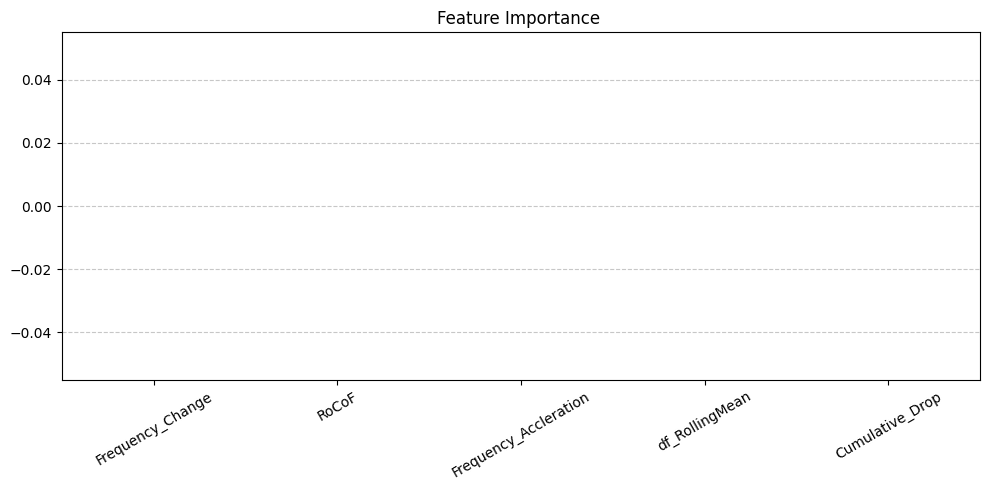

In [80]:
crash_universe = processing_mat_file("simulation_data_crash.mat", is_recovery=False)
recovery_universe = processing_mat_file("simulation_data_recovery.mat", is_recovery=True)
data_frame = pd.concat([crash_universe, recovery_universe], axis=0).reset_index(drop=True)

GridMind_Model = new_training_function(model = RandomForestClassifier(n_estimators=100,random_state=42),
                                x = data_frame[features],
                                y= data_frame["Future_Collaspe_Risk"])

In [81]:
def No_Collaspe_Test(file_name):

    raw_test_data = loadmat(file_name)
    t_test = raw_test_data["t"].squeeze()
    df_test = raw_test_data["df"].squeeze()

    test_df = pd.DataFrame({
                                "Time": t_test,
                                "Frequency_Change": df_test
                            })

    dt_test = test_df["Time"].diff().mean()
    test_df["RoCoF"] = test_df["Frequency_Change"].diff() / dt_test
    test_df["Collaspe_Risk"] = 0
    FORECAST_STEPS = 3
    test_df["Future_Collaspe_Risk"] = test_df["Collaspe_Risk"].shift(-FORECAST_STEPS)
    test_df["Frequency_Accleration"] = test_df["RoCoF"].diff() / dt_test
    test_df["df_RollingMean"] = test_df["Frequency_Change"].rolling(window = 3).mean()
    test_df["Cumulative_Drop"] = test_df["Frequency_Change"].cumsum() * dt_test


    test_df = test_df.dropna().reset_index(drop=True)

    x_test = test_df[features]
    y_test = test_df["Future_Collaspe_Risk"]

    model_prediction = GridMind_Model.predict(x_test)

    fig,axs = plt.subplots(figsize = [10,3])
    cm_test = confusion_matrix(y_test, model_prediction,
                               labels = [0,1])
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                    display_labels=["Safe Grid (0)", "Collapse Risk (1)"])
    disp_test.plot(cmap="Blues",ax = axs)
    plt.title("CONFUSION MATRIX : REALITY VS PREDICTION")
    plt.tight_layout()
    plt.show()
    

In [82]:
def Collaspe_Test(file_name):

    raw_test_data = loadmat(file_name)
    t_test = raw_test_data["t"].squeeze()
    df_test = raw_test_data["df"].squeeze()

    test_df = pd.DataFrame({
                                "Time": t_test,
                                "Frequency_Change": df_test
                            })

    dt_test = test_df["Time"].diff().mean()
    test_df["RoCoF"] = test_df["Frequency_Change"].diff() / dt_test

    critical_threshold = -5e-4 
    test_df["Collaspe_Risk"] = (test_df["Frequency_Change"] < critical_threshold).astype(int)
    
    FORECAST_STEPS = 3
    test_df["Future_Collaspe_Risk"] = test_df["Collaspe_Risk"].shift(-FORECAST_STEPS)
    test_df["Frequency_Accleration"] = test_df["RoCoF"].diff() / dt_test
    test_df["df_RollingMean"] = test_df["Frequency_Change"].rolling(window = 3).mean()
    test_df["Cumulative_Drop"] = test_df["Frequency_Change"].cumsum() * dt_test


    test_df = test_df.dropna().reset_index(drop=True)

    x_test = test_df[features]
    y_test = test_df["Future_Collaspe_Risk"]

    model_prediction = GridMind_Model.predict(x_test)

    fig,axs = plt.subplots(figsize = [10,3])
    cm_test = confusion_matrix(y_test, model_prediction,
                               labels = [0,1])
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                    display_labels=["Safe Grid (0)", "Collapse Risk (1)"])
    disp_test.plot(cmap="Blues",ax = axs)
    plt.title("CONFUSION MATRIX : REALITY VS PREDICTION")
    plt.tight_layout()
    plt.show()
    

Testing with previous sample data :
- Here in our previous attempt to predict the condition of the grid, we were not able to do so as our model was trained only on the data where the grid had faced the situation of collaspe, now lets add this same data and see if our model predicts that our grid is going to collaspe or not.

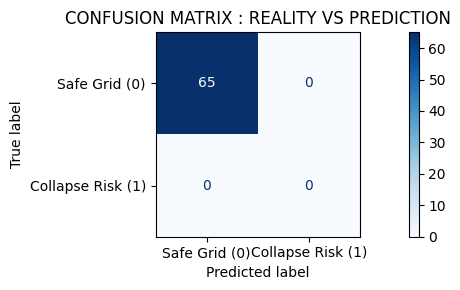

In [83]:
No_Collaspe_Test("simulation_data_recovery.mat")

Conclusions :
- We have successfully trained our model such that it can make predict both cases where the grid will collaspe or governor will just take the control and prevent the system from further collaspe.
- So our model is working fairly well here, now lets further test the model and see if it can handle extremly stressful situation of the power grid.

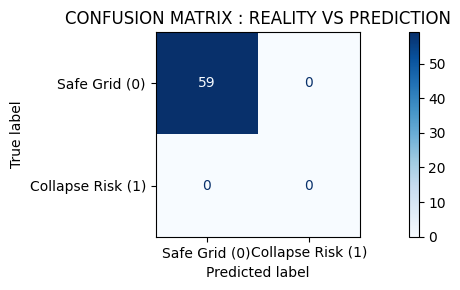

In [84]:
# REFINING TESTING PROCESS

No_Collaspe_Test("simulation_data_double_crash_test.mat")

Conclusions :
- Here we have seen that our model is doing fairly well in the first nadir of the frequency drop, as it is showing consistent reasult with the true value, but when the second nadir hits the system then our model is unable to predict that the grid has collasped.

- So we need to make our model more robust to this kind of situation, lets get going for that then.

---
THIRD MODEL TRAINING :
- Just as the previous cases, lets expose our AI model to the situation where it must handle both cases where the grid collaspes or it suffers from double nadir problem.

- To solve this issue, we are going to add the data from our double nadir fault to our dataframe and ReTrain our model and make it robust against this type of training too.

--- MODEL REPORT ----
MODEL TYPE : RandomForestClassifier(random_state=42)
CV SCORE : 1.0


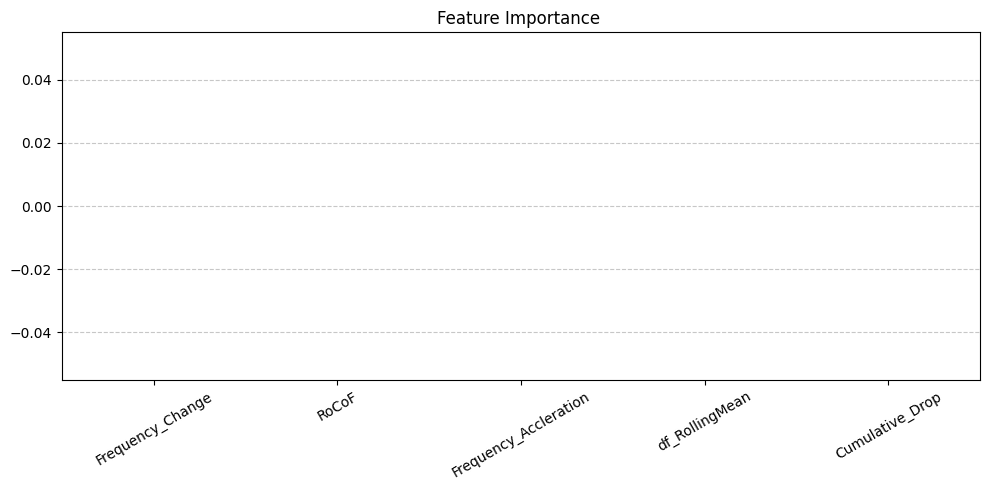

In [85]:
double_crash = processing_mat_file("simulation_data_double_crash_test.mat",is_recovery=True)

data_frame = pd.concat([data_frame, double_crash], axis=0).reset_index(drop=True)

GridMind_Model = new_training_function(model = RandomForestClassifier(n_estimators=100,random_state=42),
                                x = data_frame[features],
                                y= data_frame["Future_Collaspe_Risk"])

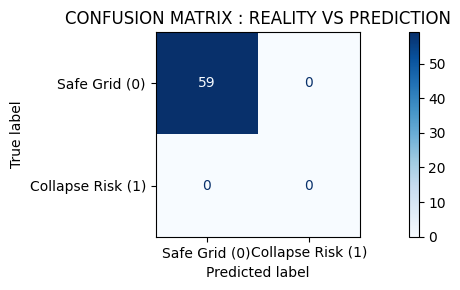

In [86]:
No_Collaspe_Test("simulation_data_double_crash_test.mat")

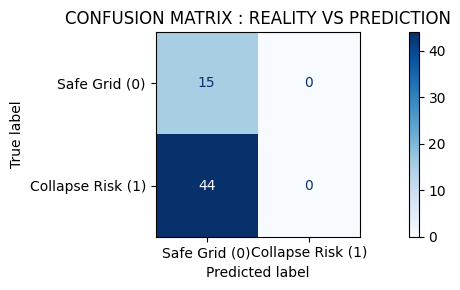

In [87]:
Collaspe_Test("simulation_data_collaspe_test.mat")

---
Causes of Bad Prediction :
- Here the main cause for this outbreak is feature value mismatch, we know that our major entity frequency change is in the order of 1e-4 as per simulink, so rest dervied quantities are also in that range, But it doesnt occur the same for the cumulative drop.

- Our Cumulitive drop is an entity that goes on increasing with time, it reperesents the stress applied on the grid during the time of crash or any other thing. So if the simulation time goes on increasing then this value will go on increasing and it will dominate the ground.

- Our Random Forest model will just look at this cumulative drop feature and decide the prediction which is not what we intend to have, so lets fix this problem


In [88]:
def New_Collaspe_Test(file_name):

    raw_test_data = loadmat(file_name)
    t_test = raw_test_data["t"].squeeze()
    df_test = raw_test_data["df"].squeeze()

    test_df = pd.DataFrame({
                                "Time": t_test,
                                "Frequency_Change": df_test
                            })

    dt_test = test_df["Time"].diff().mean()
    test_df["RoCoF"] = test_df["Frequency_Change"].diff() / dt_test

    critical_threshold = -5e-4 
    test_df["Collaspe_Risk"] = (test_df["Frequency_Change"] < critical_threshold).astype(int)
    
    FORECAST_STEPS = 3
    test_df["Future_Collaspe_Risk"] = test_df["Collaspe_Risk"].shift(-FORECAST_STEPS)
    test_df["Frequency_Accleration"] = test_df["RoCoF"].diff() / dt_test
    test_df["df_RollingMean"] = test_df["Frequency_Change"].rolling(window = 3).mean()
    test_df["Cumulative_Drop"] = test_df["Frequency_Change"].rolling(window = 50,
                            min_periods = 1).sum() * dt_test


    test_df = test_df.dropna().reset_index(drop=True)

    x_test = test_df[features]
    y_test = test_df["Future_Collaspe_Risk"]

    model_prediction = GridMind_Model.predict(x_test)

    fig,axs = plt.subplots(figsize = [10,3])
    cm_test = confusion_matrix(y_test, model_prediction,
                               labels = [0,1])
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                    display_labels=["Safe Grid (0)", "Collapse Risk (1)"])
    disp_test.plot(cmap="Blues",ax = axs)
    plt.title("CONFUSION MATRIX : REALITY VS PREDICTION")
    plt.tight_layout()
    plt.show()
    

--- MODEL REPORT ----
MODEL TYPE : RandomForestClassifier(class_weight='balanced', random_state=42)
CV SCORE : 1.0


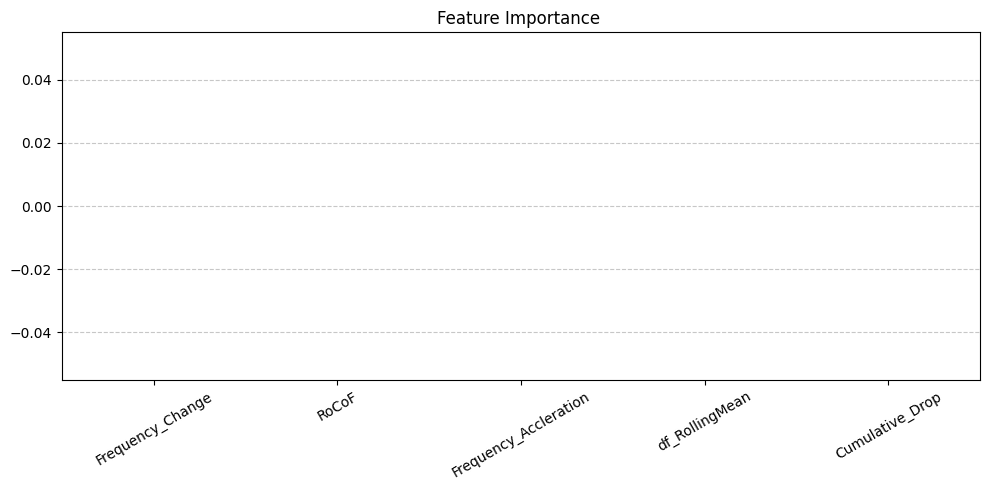

In [89]:
GridMind_Model = new_training_function(model = RandomForestClassifier(n_estimators=100,
                            class_weight="balanced",random_state=42),
                                x = data_frame[features],   
                                y= data_frame["Future_Collaspe_Risk"])

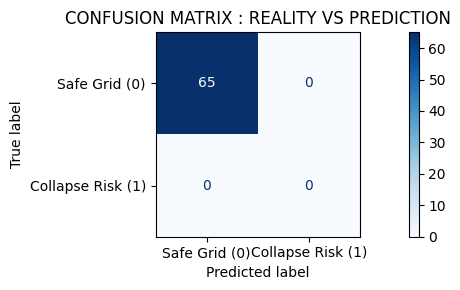

In [90]:

No_Collaspe_Test("simulation_data_recovery.mat")